![SNOTEL](images/snotel.jpg)

# Retrieve and Analyze Snotel data for a watershed of interest

This notebook supports the CIROH HydroLearn module Introduction to Seasonal Snow Observations, Modeling, and Analysis, demonstrating how to access NRCS SNOTEL data, in particular,  snow-water-equivalent. 

Supplementary Code:

To simplify this notebook, we developed and import several helper functions from the supporting_scripts folder to streamline data retrieval, data processing, and visualization. 
We encourage advanced users to explore all of the helper scripts in teh supporting_scripts folder.
For example, while this exercise focuses on a river basin in California, there is a script for retrieving SNOTEL observational data for sites located in other states utilizing the traditional site identification number.

Similar to the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/), the USDA NRCS SNOTEL program has an [interactive map system](https://nwcc-apps.sc.egov.usda.gov/imap/#version=2&elements=&networks=!&states=!&counties=!&hucs=&minElevation=&maxElevation=&elementSelectType=any&activeOnly=true&activeForecastPointsOnly=true&hucLabels=false&hucIdLabels=false&hucParameterLabels=true&stationLabels=&overlays=&hucOverlays=&basinOpacity=75&basinNoDataOpacity=25&basemapOpacity=100&maskOpacity=0&mode=data&openSections=dataElement,parameter,date,basin,options,elements,location,networks&controlsOpen=true&popup=&popupMulti=&popupBasin=&base=esriNgwm&displayType=station&basinType=6&dataElement=WTEQ&depth=-8&parameter=PCTMED&frequency=DAILY&duration=I&customDuration=&dayPart=E&monthPart=E&forecastPubDay=1&forecastExceedance=50&useMixedPast=true&seqColor=1&divColor=7&scaleType=D&scaleMin=&scaleMax=&referencePeriodType=POR&referenceBegin=1991&referenceEnd=2020&minimumYears=20&hucAssociations=true&relativeDate=-1&lat=42.300&lon=-114.300&zoom=4.5).


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [16]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [17]:
nldi = NLDI()
usgs_gage_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

Collect watershed and reach vectors using the pynhd module.

In [18]:
nldi = NLDI()

#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file("files/TuolumneRiverBasin.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

Create and interactive map to display the watershed.

In [19]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust Snotel.ipynb
mapping.basin_mapping(basin, site_feature)

![Basin](./images/basin.png)

# 2. Identify SNOTEL sites within a spatial domain

Here, we will read a geojson file from the web containing the geospatial information for all SNOTEL sites. 
Once loaded, the script will use the basin geometry (in the form of a polygon in the GeoDataFrame) to clip all SNOTEL sites located within the boundaries of the basin.

In [20]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
basin_poly = basin.geometry.iloc[0]
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin_poly)]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,TUM,Tuolumne Meadows,CCSS,2621.280,37.876406,-119.348096,California,180400090102,11SKB,Sierra Nevada,2004-10-01,2026-03-04,True,POINT (-119.3481 37.87641)
1,TES,Tioga Pass Entry Station,CCSS,3031.236,37.910870,-119.258507,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-03,True,POINT (-119.25851 37.91087)
2,DAN,Dana Meadows,CCSS,2987.040,37.896162,-119.257260,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-04,True,POINT (-119.25726 37.89616)
3,SLI,Slide Canyon,CCSS,2804.160,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-03-04,True,POINT (-119.43188 38.09123)


Add the SNOTEL monitoring station locations to the map

In [21]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

![basinsnotel](./images/basinsnotel.png)

# 3. Retrieve data for the selected sites

The following uses the [getData.py](./supporting_scripts/getData.py) script to download SNOTEL data for the sites within the domain. Inputs to this script include the SNOTEL site name, site ID, and state abbreviation, which are retrieved from the geodataframe above. Additional inputs include the start and end dates, as well as the path to save the outputs.

In [ ]:
# # Use the getData module to retrieve data 
# OutputFolder = 'files/SNOTEL'
# if not os.path.exists(OutputFolder):
#     os.makedirs(OutputFolder)

# for i in gdf_in_bbox.index:
#     getData.getCaliSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)
#     #getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)

# 4.  Process the data to enable plotting and analysis

In [23]:
fp = "files/SNOTEL/df_TUM_Ca_SNTL.csv"

df = pd.read_csv(fp, comment="#")  # ignores all the NRCS header/comment lines

# rename site-specific SWE column -> generic SWE column (in meters)
site_swe_col = [c for c in df.columns if "Snow Water Equivalent" in c][0]
df = df.rename(columns={site_swe_col: "Snow Water Equivalent (m) Start of Day Values"})

# Date + Water Year
df["Date"] = pd.to_datetime(df["Date"])
df["Water_Year"] = df["Date"].dt.year + (df["Date"].dt.month >= 10).astype(int)

# inches -> meters (your file is in inches)
df["Snow Water Equivalent (m) Start of Day Values"] = (
    pd.to_numeric(df["Snow Water Equivalent (m) Start of Day Values"], errors="coerce") * 0.0254
)

df.to_csv(fp, index=False)
df.head()

,Date,Snow Water Equivalent (m) Start of Day Values,Water_Year
0,2004-10-01,0.0,2005
1,2004-10-02,0.0,2005
2,2004-10-03,0.0,2005
3,2004-10-04,0.0,2005
4,2004-10-05,0.0,2005


In [15]:
from supporting_scripts import dataprocessing

sites = ["TUM"]
stateab = "Ca"
WY = 2005

sitedict = {}

for site in sites:
    df = dataprocessing.processSNOTEL(site, stateab, WY)
    sitedict[site] = df

sitedict["TUM"].head()

TUM
Dropping 2005 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


,M,D,2005_SWE_in,2006_SWE_in,2007_SWE_in,2008_SWE_in,2009_SWE_in,2010_SWE_in,2011_SWE_in,2012_SWE_in,...,2022_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-05


# 5. Make a snow report for WY2019

We use the script [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **SNOTELPlots()** function to generate a plot of all snotel sites of interest. The function takes in the following inputs:
* A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* geodataframe with a bounding box from the above step
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

In [21]:
gdf_in_bbox = pd.DataFrame({
    "code": ["TUM"],
    "name": ["Tuolumne Meadows"]
})

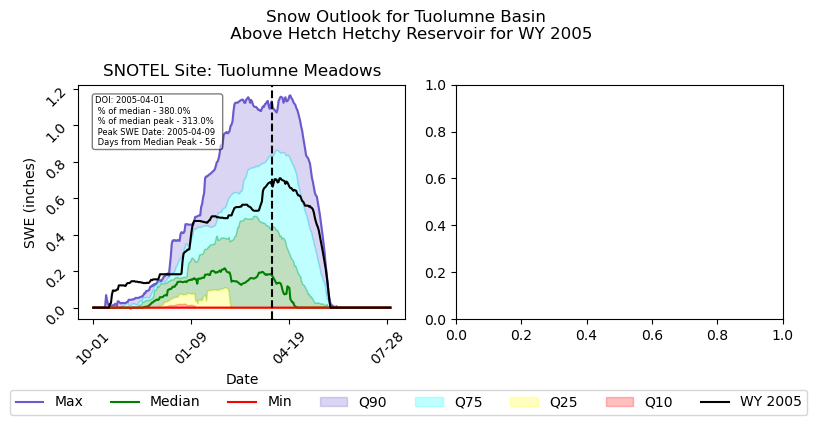

In [25]:
watershed = "Tuolumne"
AOI = "Above Hetch Hetchy Reservoir"
DOI = "04-01"

SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI, DOI)

In [24]:
import matplotlib.pyplot as plt
plt.close("all")

# 6. Generate a Basin Snow report

By using the [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **catchmentSNOTELAnalysis()** function, the user will be able to develop a statistical snow analysis based on the mean values of each SNOTEL observation station within the catchment.

The function takes in the following inputs:
**A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

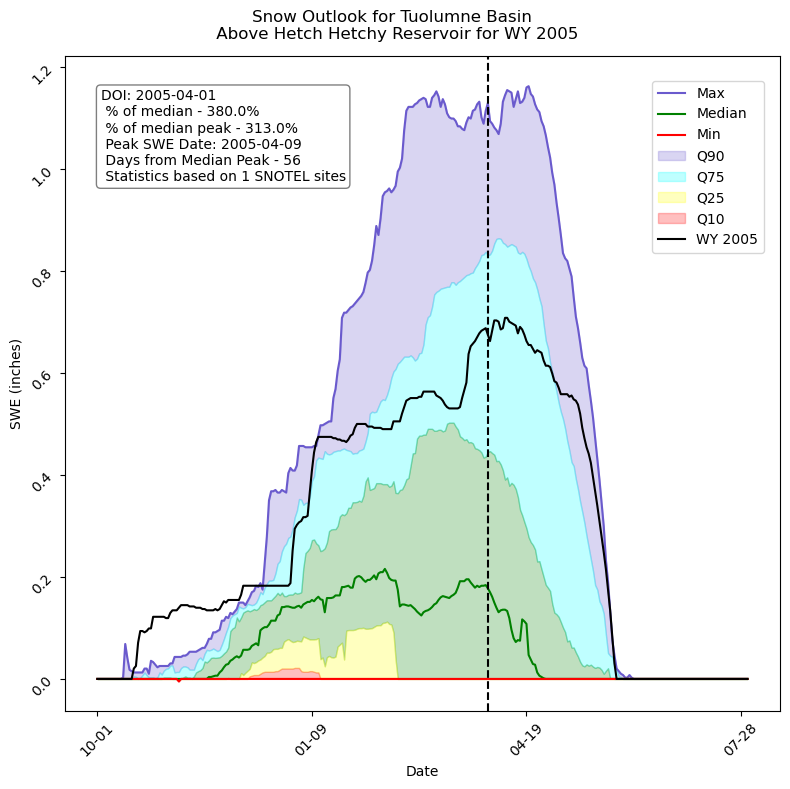

In [26]:
watershed = "Tuolumne"
AOI = 'Above Hetch Hetchy Reservoir'
DOI = '04-01' #must be in MM-DD form

SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

# Exercise: Catchment delineation, geospatial tools to retrieve site information, automated data collection, and visualization 

Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/) to identify a NWIS id with high eleveation SNOTEL sites in the Great Salt Lake Basin. Feel free to work backwards and use the [ USDA NRCS SNOTELinteractive map system](https://nwcc-apps.sc.egov.usda.gov/imap/#version=2&elements=&networks=!&states=!&counties=!&hucs=&minElevation=&maxElevation=&elementSelectType=any&activeOnly=true&activeForecastPointsOnly=true&hucLabels=false&hucIdLabels=false&hucParameterLabels=true&stationLabels=&overlays=&hucOverlays=&basinOpacity=75&basinNoDataOpacity=25&basemapOpacity=100&maskOpacity=0&mode=data&openSections=dataElement,parameter,date,basin,options,elements,location,networks&controlsOpen=true&popup=&popupMulti=&popupBasin=&base=esriNgwm&displayType=station&basinType=6&dataElement=WTEQ&depth=-8&parameter=PCTMED&frequency=DAILY&duration=I&customDuration=&dayPart=E&monthPart=E&forecastPubDay=1&forecastExceedance=50&useMixedPast=true&seqColor=1&divColor=7&scaleType=D&scaleMin=&scaleMax=&referencePeriodType=POR&referenceBegin=1991&referenceEnd=2020&minimumYears=20&hucAssociations=true&relativeDate=-1&lat=42.300&lon=-114.300&zoom=4.5) to find a basin upstream of a NWIS site that has 3-4 Snotel sites.

Conduct/repeat the following activities in a new notebook that you create, called: **My_SNOTEL_Analysis.ipynb**:
1. Create a delineated Watershed Map for the area upstream of the NWIS site
2. Retrieve data for the selected sites
3. Process the data to enable plotting and analysis
4. Make a snow report for WY2026
5. Generate a Basin Snow report

*note, make sure you correctly name any files for your particlular watershed of interest
